# The Odd-Lot Ratio — do small retail trades still mark the wrong side? 🪙
### The oldest 'dumb-money' fade signal, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Alive_post-decimalization%3F: Busted](https://img.shields.io/badge/Alive_post--decimalization%3F-Busted-8b949e?style=flat-square)

Back when the stock market ran on paper tickets, a trade of **fewer than 100 shares** was called an *odd lot* — and it was the fingerprint of the little guy, the small investor who couldn't afford a round 100-share lot. Wall Street lore said the odd-lot crowd was *reliably wrong*: they bought at the top and sold at the bottom. So the **odd-lot theory** (Garfield Drew, 1950s) said: watch what the odd-lotters do, and do the **opposite**. When they're buying like crazy, sell. When they're panic-selling, buy. **Fade the dumb money.**

Did it ever work? Maybe, once. Does it work now? We test the fade cleanly — and find it's **dead**, for a very concrete reason: today most 'odd lots' aren't retail at all.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool. **Synthetic-only**: a clean, long odd-lot ratio series is proprietary, so there is no real tape to fetch — the honest default is a 'modern' world where the fade is switched off. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from odd_lot_ratio import data, strategy as st

# SYNTHETIC-ONLY study: the modern post-decimalization null (fade_alpha = 0) is the headline tape.
# No real odd-lot ratio series is available on a free retail stack -> no real-tape banner anywhere.
NULL, _ = data.synthetic_series(fade_alpha=0.0)          # modern null (the honest default)
EDGE, _ = data.synthetic_series(fade_alpha=0.0020)       # the OLD dumb-money world (control)
print("synthetic modern-null tape:", len(NULL), "weeks, fp", data.fingerprint(NULL))


synthetic modern-null tape: 1039 weeks, fp 2659c7bf0fd0


## The answer first 🎯

| Question | Answer |
|---|---|
| Does fading odd-lot buying pay today? | **No.** On the modern tape the 'panic' weeks earned **+8.1%/yr** and the 'euphoria' weeks **+9.7%/yr** — the crowd's euphoria was, if anything, *slightly better*, the opposite of the fade. |
| Is that just noise? | **It's all noise** — a shuffle test puts the odds at *p* = 0.62, and the signal's direction flips from window to window. |
| Could you trade it? | **No.** A weekly contrarian overlay *loses* **-2.7%/yr** after costs, trading itself over 25× a year. |
| So why is it dead? | **Because 'odd lot' no longer means 'retail'.** Since decimalization (2001), computers chop one big order into thousands of tiny ones — most odd lots today are *machines*, not mom-and-pop. |

> The fade was real folklore when odd lots really were the little guy. The premise died with penny ticks and algorithmic order-slicing — and the odd-lot data itself was proprietary and off the public tape for years.

## 1 · The claim

> *"The odd-lot crowd is chronically wrong — so fade them."* — the odd-lot theory (Garfield Drew, 1950s).

The idea: small investors are emotional. They chase rallies (buying tops) and flee crashes (selling bottoms). If you could *see* what they were doing — via the odd-lot ratio, the share of small-lot volume that was buying vs selling — you'd have a contrarian crystal ball: heavy odd-lot buying = a top is near = sell.

## 2 · So what?

If true, it's free money from other people's mistakes — the purest form of a sentiment edge. It's also a close cousin of the desk's survey-sentiment study ([257 AAII-Sentiment](../../257-aaii-sentiment/)), which asks the *same* contrarian question of a bull-bear survey. The difference: AAII measures *stated opinion*; the odd-lot ratio measures *actual order flow*. Flow should be harder to fake — if the theory holds anywhere, it should hold here.

## 3 · How would we even know?

1. **Watch the odd-lot ratio** each week — the share of small-lot volume that's buying (high = euphoric, low = panicky).
2. **Fade it.** When last week's ratio was high, go short/underweight this week; when it was low, go long. (We use *last* week's ratio, so there's no peeking — one week's lag.)
3. **Check who won.** Did the 'panic' weeks (fade said buy) beat the 'euphoria' weeks (fade said sell)? The theory says yes.

Catch: **there is no free odd-lot ratio series.** It lives in proprietary market data, and odd lots weren't even on the public tape until 2013–14. So we build a *synthetic* tape with a knob — turn the fade edge **on** (the old world) or **off** (today) — and see what a clean test does with each.

## 4 · The teardown — let's actually look

**On the modern tape (fade switched off), did panic beat euphoria?**

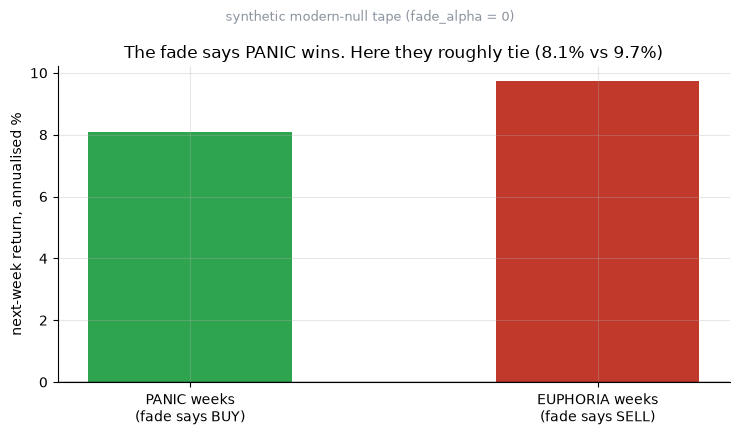

panic +8.1%/yr  vs  euphoria +9.7%/yr  ->  spread -1.6%/yr (t -0.20)


In [2]:
rs = st.regime_sort(NULL)
panic, euph = rs['panic_ann']*100, rs['euphoria_ann']*100
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['PANIC weeks\n(fade says BUY)','EUPHORIA weeks\n(fade says SELL)'], [panic, euph],
       color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('next-week return, annualised %')
ax.set_title(f'The fade says PANIC wins. Here they roughly tie ({panic:.1f}% vs {euph:.1f}%)')
fig.suptitle('synthetic modern-null tape (fade_alpha = 0)', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(f'panic +{panic:.1f}%/yr  vs  euphoria +{euph:.1f}%/yr  ->  spread {rs["spread_ann"]*100:+.1f}%/yr (t {rs["t"]:+.2f})')

There's the tell: the fade predicts the **panic** weeks win. On the modern tape they **tie** (+8.1% vs +9.7%) — a spread of -1.6%/yr with a *t* of -0.2, i.e. nothing. The odd-lot crowd's 'euphoria' weeks weren't worse; small trades no longer mark the wrong side.

**Is the signal just *gone*, or does its direction wobble?** Run the fade over four slices of the tape:

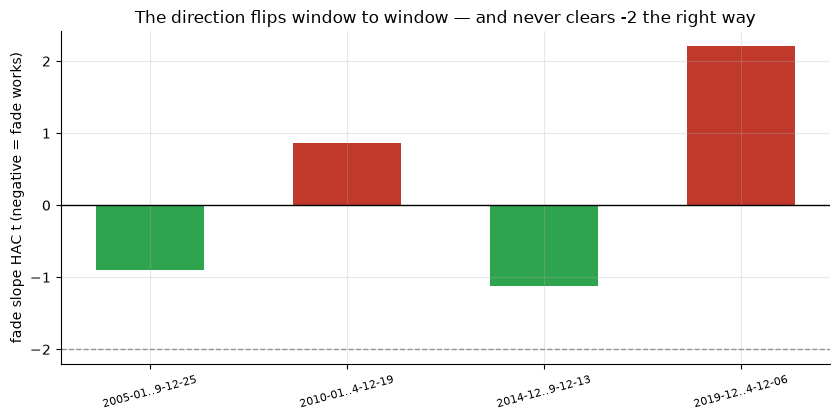

HAC t by window: [-0.9, 0.87, -1.12, 2.2]


In [3]:
rows = st.window_sweep(NULL, n_windows=4)
labs = [w['window'][:7] + '..' + w['window'][-7:] for w in rows]
ts = [w['t'] for w in rows]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
cols = [GREEN if t < 0 else RED for t in ts]  # negative t = fade direction (correct)
ax.bar(range(len(ts)), ts, color=cols, width=.55)
ax.set_xticks(range(len(ts))); ax.set_xticklabels(labs, rotation=15, fontsize=8)
ax.axhline(0, c='k', lw=1); ax.axhline(-2, ls='--', c=GREY, lw=1)
ax.set_ylabel('fade slope HAC t (negative = fade works)')
ax.set_title('The direction flips window to window — and never clears -2 the right way')
plt.tight_layout(); plt.show()
print('HAC t by window:', [round(t,2) for t in ts])

The direction **flips**: some windows lean faintly the fade way (negative), others the *anti*-fade way (positive) — and the only window that reaches the |*t*|=2 significance bar does so with the **wrong** sign. A signal whose direction depends on the calendar isn't a signal.

## 5 · The verdict

- **Signal — None.** The fade is statistically zero (*t* +0.5, placebo *p* 0.62), the panic/euphoria spread is a tie, and the direction flips across windows. Synthetic-only, so it can't rate above `WEAK`/`NONE` anyway.
- **Tradability — Mirage.** The overlay loses money and churns 26× a year.
- **Alive post-decimalization? — Busted.** The premise (odd lot = dumb retail money) died with penny ticks and algorithmic order-slicing.

## 6 · Could you actually trade it?

No — twice over. First, there's nothing to trade: the fade is the wrong sign and loses money. Second, even if it worked, **you couldn't get the data**: a clean, timely odd-lot ratio is proprietary market-data plumbing, not something on a free retail feed. The signal the theory rests on isn't just dead — for most people it was never visible.

## 7 · Going further 🚪

- **The engine isn't broken — the world changed.** In [02_for_the_quants](02_for_the_quants.ipynb) we *plant* the old dumb-money fade and watch a clean test bank it cleanly (the slope-*t* sails past −2). Switch the fade off (today) and the test correctly reads zero.
- **The survey cousin.** [257 AAII-Sentiment](../../257-aaii-sentiment/) runs the same contrarian idea on a bull-bear *survey* — directionally right but weak.

*Think the odd-lot fade is alive on real, point-in-time tape data? Fork this, wire in a genuine consolidated-tape odd-lot ratio, and show the fade slope clearing t = −2 the right way after decimalization.*